# Sales Analytics — Data Analysis

This notebook adds a Python/Pandas analysis layer on top of the Flask + SQLite sales dashboard.

**Workflow:**
1. Load data from `sales_analytics.db`
2. Clean and validate the data
3. Build a combined sales fact table
4. Visualize revenue trends, category performance, and top products
5. Summarize findings


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Load Data

In [2]:
DB_PATH = "sales_analytics.db"

conn = sqlite3.connect(DB_PATH)

orders = pd.read_sql("SELECT * FROM orders", conn)
order_items = pd.read_sql("SELECT * FROM order_items", conn)
products = pd.read_sql("SELECT * FROM products", conn)
categories = pd.read_sql("SELECT * FROM categories", conn)
customers = pd.read_sql("SELECT * FROM customers", conn)

conn.close()

print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("products:", products.shape)
print("categories:", categories.shape)
print("customers:", customers.shape)

orders: (24, 4)
order_items: (48, 5)
products: (10, 5)
categories: (5, 2)
customers: (8, 4)


In [3]:
orders.head()

,order_id,customer_id,order_date,status
0,1,1,2024-01-05,Completed
1,2,2,2024-01-12,Completed
2,3,3,2024-02-03,Completed
3,4,4,2024-02-18,Completed
4,5,5,2024-03-07,Completed


## 2. Data Cleaning

Checks performed:
- Missing values across all tables
- Duplicate rows in `order_items`
- Correct data types (dates, numeric fields)


In [4]:
# Missing values per table
for name, df in [
    ("orders", orders),
    ("order_items", order_items),
    ("products", products),
    ("categories", categories),
    ("customers", customers),
]:
    null_count = df.isnull().sum().sum()
    print(f"{name}: {null_count} missing values")

# Duplicate order_items
print("\nDuplicate order_items rows:", order_items.duplicated().sum())

orders: 0 missing values
order_items: 0 missing values
products: 0 missing values
categories: 0 missing values
customers: 0 missing values

Duplicate order_items rows: 0


In [5]:
# Convert order_date to datetime
orders["order_date"] = pd.to_datetime(orders["order_date"])

# Confirm dtypes look correct
orders.dtypes

order_id                int64
customer_id             int64
order_date     datetime64[us]
status                    str
dtype: object

## 3. Build the Sales Fact Table

Joins `order_items` with `orders`, `products`, `categories`, and `customers` into a single analysis-ready table, and computes `line_revenue` (quantity × unit price) for each order line.

In [6]:
sales = (
    order_items
    .merge(orders, on="order_id")
    .merge(products, on="product_id", suffixes=("", "_product"))
    .merge(categories, on="category_id")
    .merge(customers, on="customer_id")
)

# unit_price from order_items reflects the price at time of sale
sales["line_revenue"] = sales["quantity"] * sales["unit_price"]
sales["month"] = sales["order_date"].dt.to_period("M").astype(str)

sales[["order_date", "product_name", "category_name", "city",
       "quantity", "unit_price", "line_revenue"]].head()

,order_date,product_name,category_name,city,quantity,unit_price,line_revenue
0,2024-01-05,Samsung Galaxy S24,Electronics,Riyadh,1,"3,200.00","3,200.00"
1,2024-01-05,Arabic Coffee Pack,Food & Beverages,Riyadh,2,85.00,170.00
2,2024-01-12,iPhone 15,Electronics,Jeddah,1,"4,500.00","4,500.00"
3,2024-01-12,Adidas T-Shirt,Clothing,Jeddah,3,120.00,360.00
4,2024-02-03,Sony Headphones WH1000,Electronics,Dammam,2,950.00,"1,900.00"


## 4. Visualizations

### 4.1 Revenue by Category

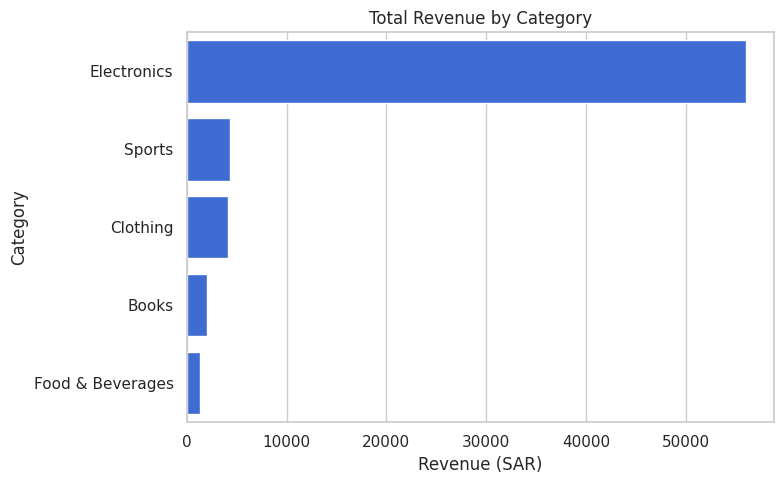

category_name
Electronics        56,050.00
Sports              4,320.00
Clothing            4,160.00
Books               2,075.00
Food & Beverages    1,360.00
Name: line_revenue, dtype: float64

In [7]:
revenue_by_category = (
    sales.groupby("category_name")["line_revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=revenue_by_category.values,
    y=revenue_by_category.index,
    color="#2563eb"
)
plt.title("Total Revenue by Category")
plt.xlabel("Revenue (SAR)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

revenue_by_category

### 4.2 Monthly Revenue Trend

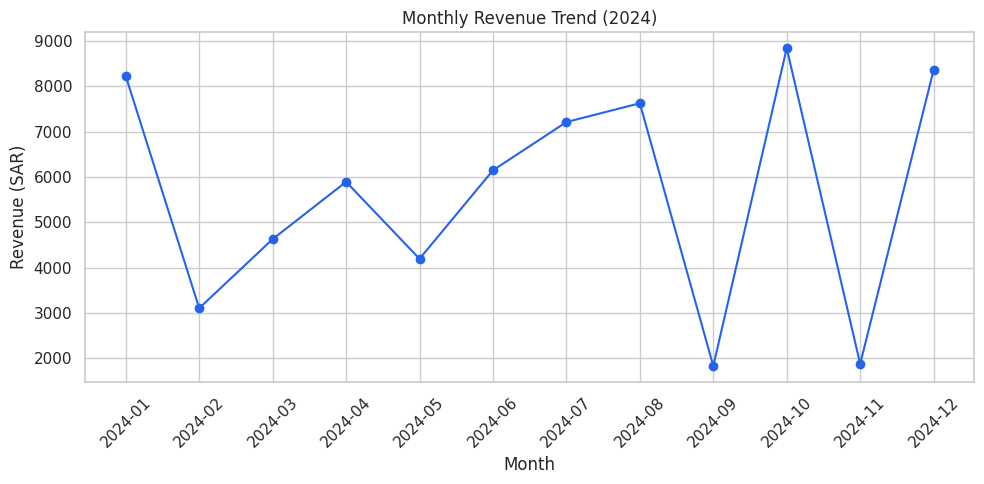

In [8]:
monthly_revenue = sales.groupby("month")["line_revenue"].sum()

plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values,
         marker="o", color="#2563eb")
plt.title("Monthly Revenue Trend (2024)")
plt.xlabel("Month")
plt.ylabel("Revenue (SAR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.3 Top 5 Products by Revenue

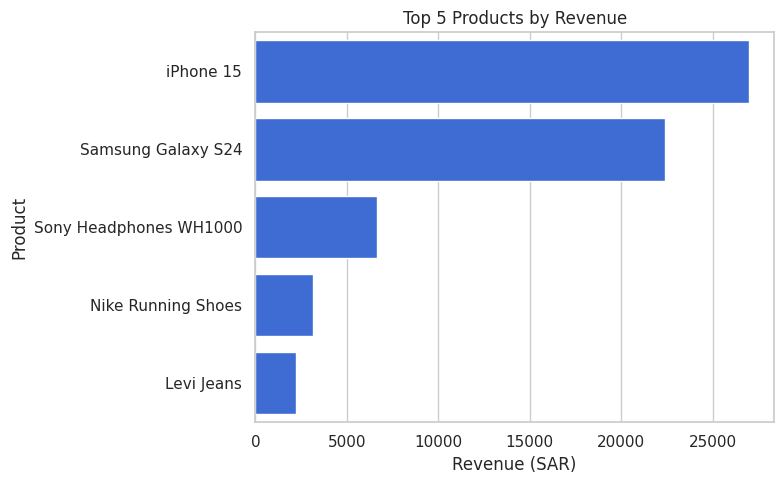

product_name
iPhone 15                27,000.00
Samsung Galaxy S24       22,400.00
Sony Headphones WH1000    6,650.00
Nike Running Shoes        3,150.00
Levi Jeans                2,240.00
Name: line_revenue, dtype: float64

In [9]:
top_products = (
    sales.groupby("product_name")["line_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=top_products.values,
    y=top_products.index,
    color="#2563eb"
)
plt.title("Top 5 Products by Revenue")
plt.xlabel("Revenue (SAR)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

top_products

### 4.4 Revenue by Customer City

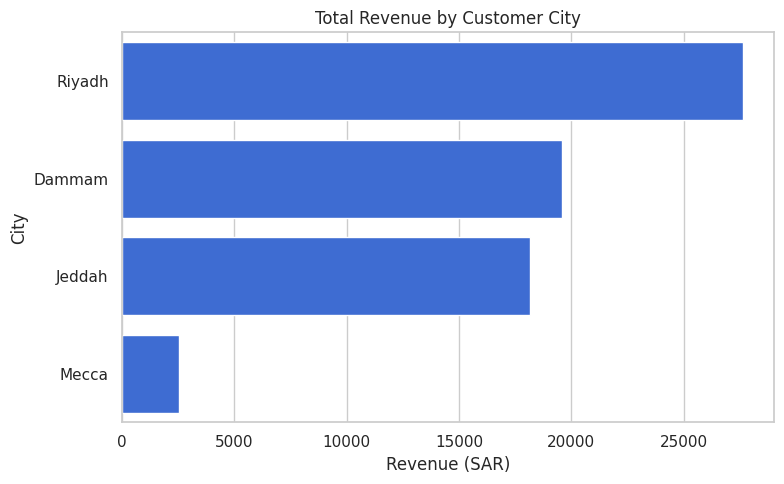

city
Riyadh   27,635.00
Dammam   19,600.00
Jeddah   18,170.00
Mecca     2,560.00
Name: line_revenue, dtype: float64

In [10]:
revenue_by_city = (
    sales.groupby("city")["line_revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=revenue_by_city.values,
    y=revenue_by_city.index,
    color="#2563eb"
)
plt.title("Total Revenue by Customer City")
plt.xlabel("Revenue (SAR)")
plt.ylabel("City")
plt.tight_layout()
plt.show()

revenue_by_city

## 5. Insights

- **Electronics drives the business.** Electronics accounts for about 82% of total revenue (56,050 of 67,965 SAR). The other four categories combined contribute roughly 18%.
- **Two products carry most of the revenue.** The iPhone 15 and Samsung Galaxy S24 alone generate about 73% of total revenue (49,400 SAR). This is a concentration risk — if either product line underperforms, total revenue drops sharply.
- **Revenue is geographically concentrated.** Riyadh, Dammam, and Jeddah account for roughly 96% of revenue, while Mecca contributes only about 4% despite having an active customer.
- **Monthly revenue is volatile, not seasonal.** With only one year of data, no clear seasonal pattern emerges — revenue swings between ~1,800 SAR (Sep, Nov) and ~8,800 SAR (Oct) month to month. More historical data would be needed to confirm any seasonal trend.
- **Data quality is clean.** No missing values and no duplicate order line items were found across all tables.
